In [32]:
import kagglehub
import pandas as pd
import numpy as np
import os

# Login and download dataset
kagglehub.login()
path = kagglehub.competition_download('amex-default-prediction')
print("Path to competition files:", path)

# Load a sample of train_data and the full train_labels
train_data_path = os.path.join(path, 'train_data.csv')
train_labels_path = os.path.join(path, 'train_labels.csv')

# Load a sample to avoid Out-Of-Memory (OOM) errors
df_sample = pd.read_csv(train_data_path, nrows=10000)
labels = pd.read_csv(train_labels_path)

print(f"\nTotal Data Points (from labels): {len(labels)}")
print(f"Number of Features (excluding customer_ID and S_2): {df_sample.shape[1] - 2}")

# Missing values in the sample
missing_total = df_sample.isnull().sum().sum()
print(f"Total missing values in sample: {missing_total}")

# Create a feature summary table based on the sample
feature_summary = []
for col in df_sample.columns:
    if col in ['customer_ID', 'S_2']:
        continue

    dtype = df_sample[col].dtype
    missing_count = df_sample[col].isnull().sum()

    if dtype == 'object' or df_sample[col].nunique() < 20:
        cat_type = 'Categorical'
        values = str(df_sample[col].dropna().unique()[:5]) + "..."
    else:
        cat_type = 'Numerical'
        values = f"Range: [{df_sample[col].min():.2f}, {df_sample[col].max():.2f}]"

    feature_summary.append({
        'Feature': col,
        'Type': cat_type,
        'Values': values,
        'Missing Values': missing_count
    })

summary_df = pd.DataFrame(feature_summary)
display(summary_df.head(20))

# Target Analysis
print("\nTarget Variable Analysis:")
print(f"Target is encoded as: {labels['target'].unique()}")
class_counts = labels['target'].value_counts(normalize=True) * 100
print("Class Distribution (Class Imbalance):")
print(class_counts)


Path to competition files: /root/.cache/kagglehub/competitions/amex-default-prediction

Total Data Points (from labels): 458913
Number of Features (excluding customer_ID and S_2): 188
Total missing values in sample: 288362


,Feature,Type,Values,Missing Values
0,P_2,Numerical,"Range: [-0.26, 1.01]",64
1,D_39,Numerical,"Range: [0.00, 4.27]",0
2,B_1,Numerical,"Range: [-0.14, 1.32]",0
3,B_2,Numerical,"Range: [0.00, 1.01]",0
4,R_1,Numerical,"Range: [0.00, 2.26]",0
5,S_3,Numerical,"Range: [-0.15, 1.80]",1752
6,D_41,Numerical,"Range: [0.00, 2.59]",0
7,B_3,Numerical,"Range: [0.00, 1.26]",0
8,D_42,Numerical,"Range: [0.00, 2.56]",8645
9,D_43,Numerical,"Range: [0.00, 2.32]",3087



Target Variable Analysis:
Target is encoded as: [0 1]
Class Distribution (Class Imbalance):
target
0    74.106639
1    25.893361
Name: proportion, dtype: float64


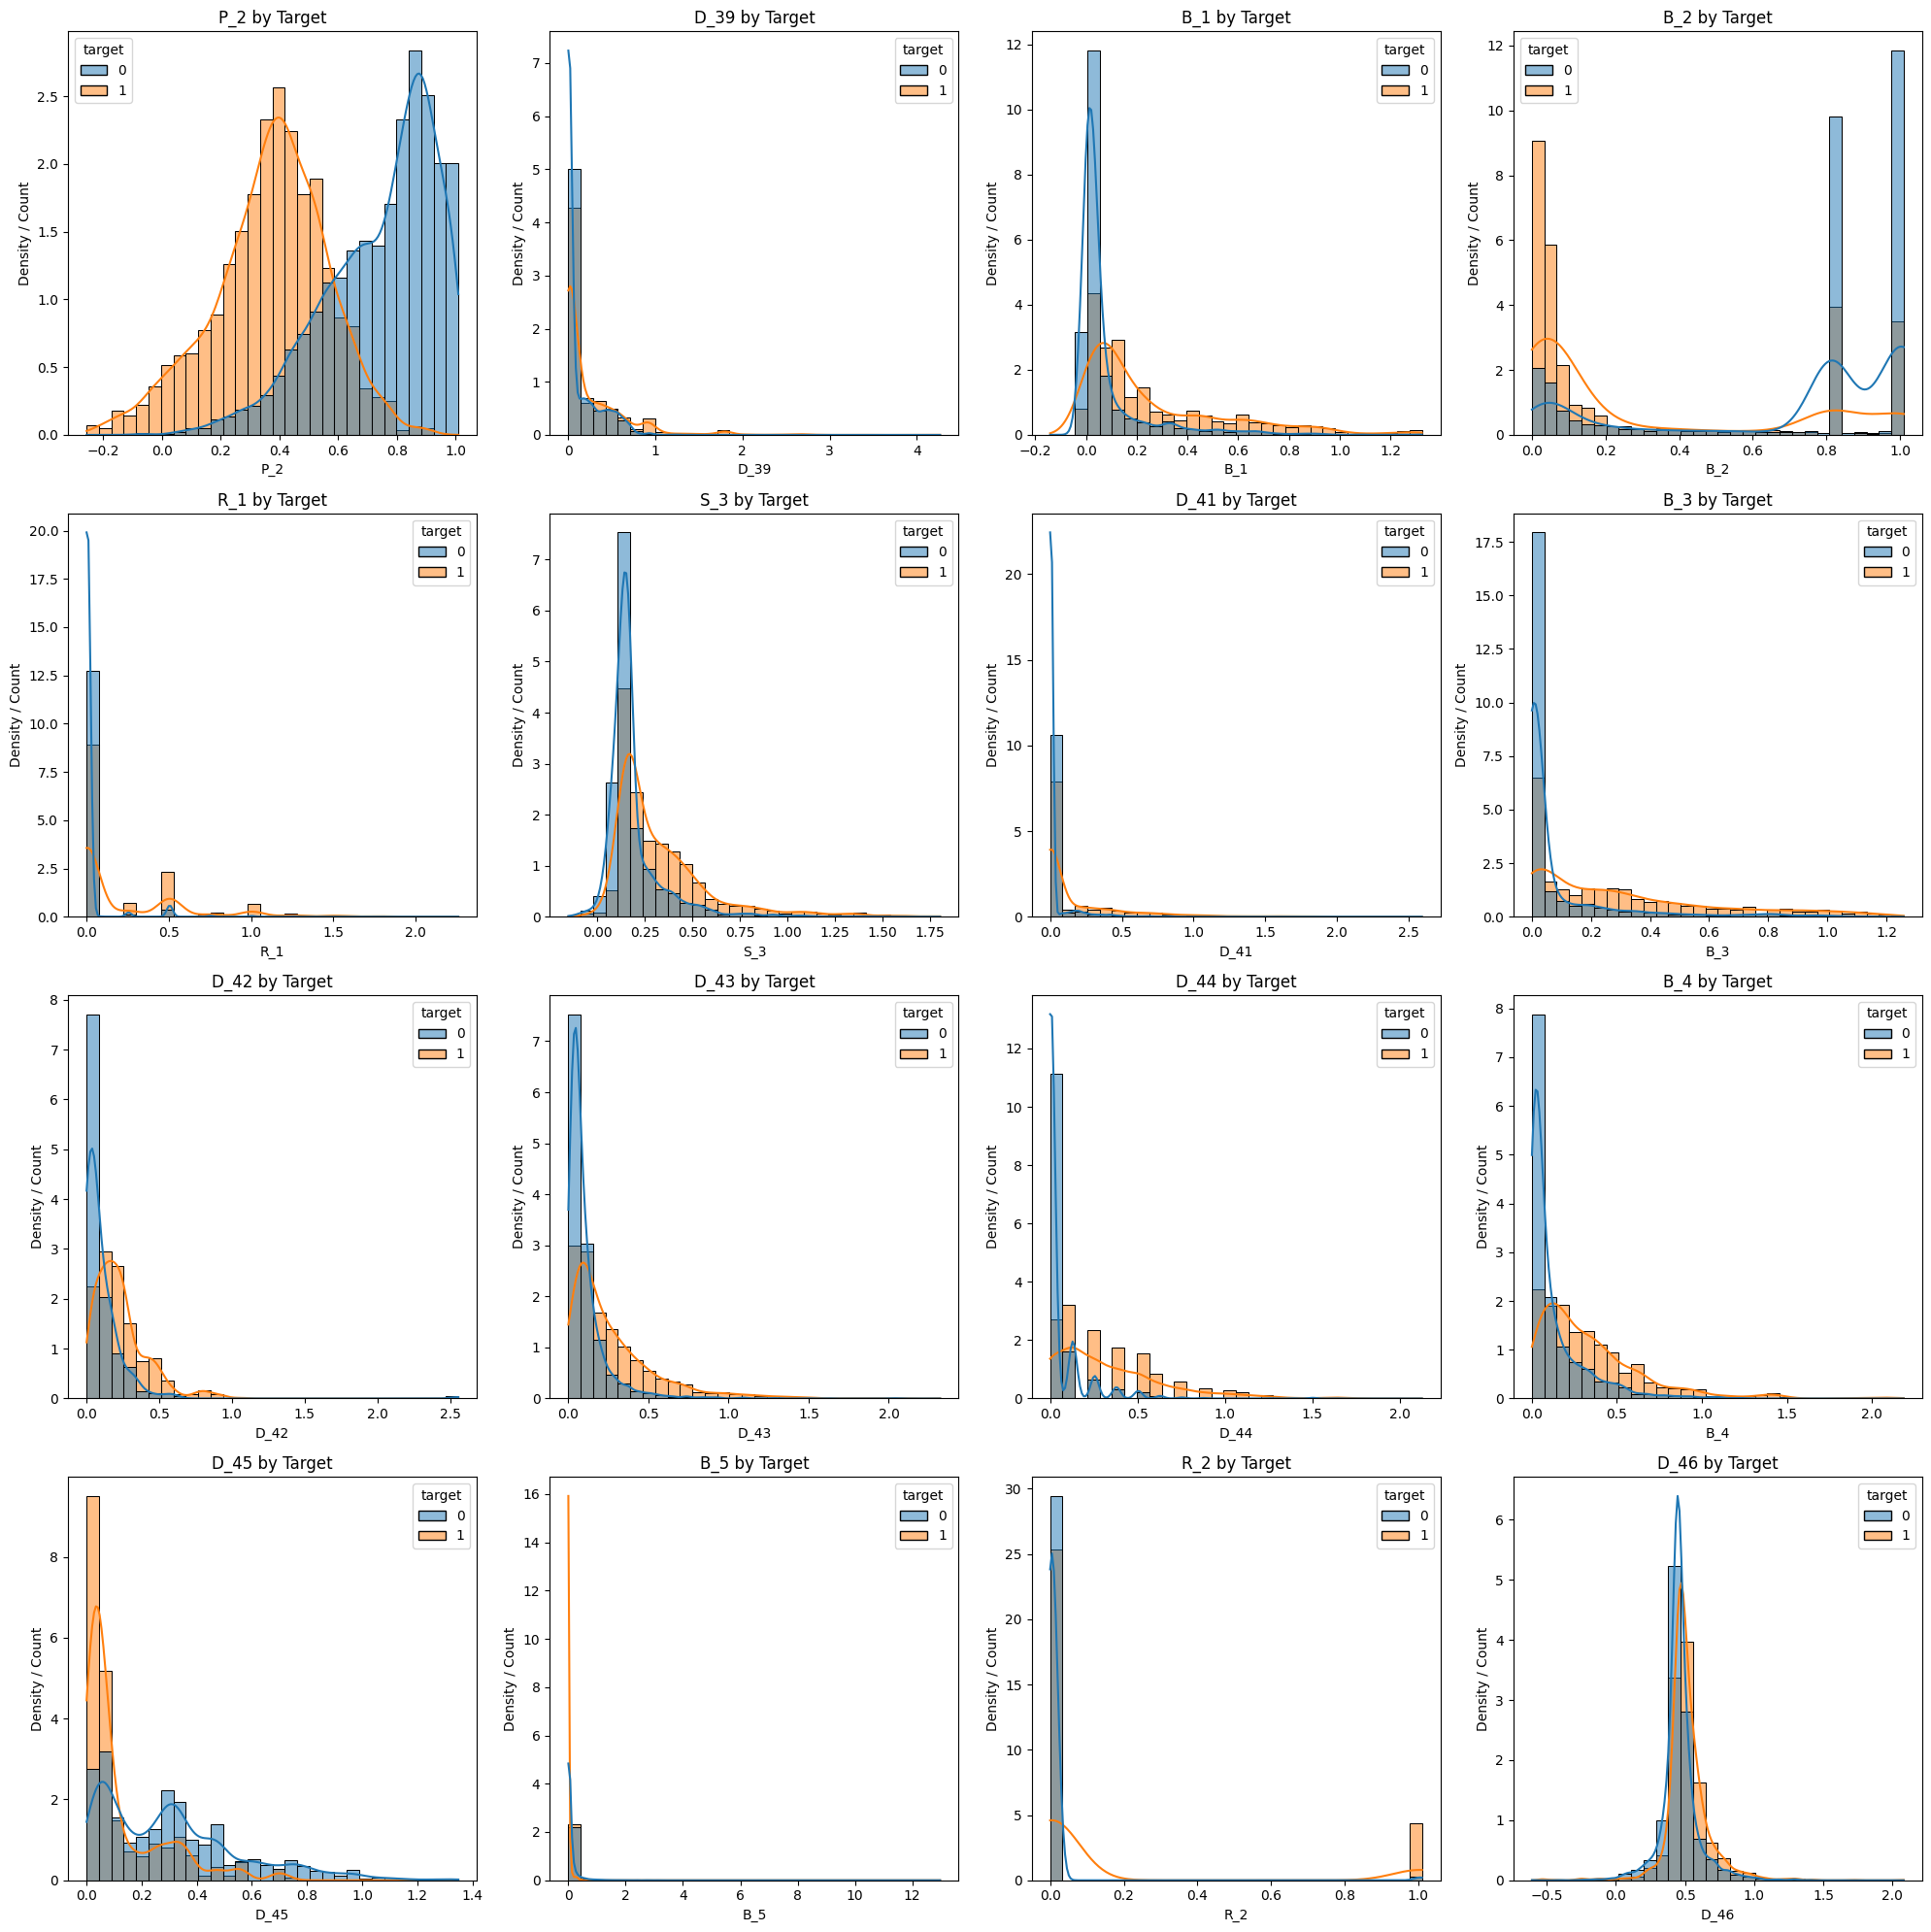

1. Separation: Look for numerical features where the blue (0) and orange (1) peaks are far apart.
2. Different Shapes: Features where one class is skewed differently than the other.
3. Categorical Differences: Categories where the ratio of Class 1 to Class 0 drastically changes compared to the baseline.


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Merge sample data with labels on customer_ID
df_merged = df_sample.merge(labels, on='customer_ID', how='inner')

# Selecting the first 16 features to visualize
features_to_plot = [col for col in df_sample.columns if col not in ['customer_ID', 'S_2']][:16]


fig = plt.figure(figsize=(20, 20))
for i, col in enumerate(features_to_plot):
    plt.subplot(4, 4, i + 1)

    # Differentiate between categorical (few unique values) and numerical
    if df_merged[col].nunique() < 20:
        sns.countplot(data=df_merged, x=col, hue='target', alpha=0.8)
    else:
        # Using stat='density' and common_norm=False to properly compare the shapes
        # despite the class imbalance (74% vs 26%)
        sns.histplot(data=df_merged, x=col, hue='target', stat='density',
                     common_norm=False, bins=30, alpha=0.5, kde=True)

    plt.title(f'{col} by Target')
    plt.xlabel(col)
    plt.ylabel('Density / Count')

plt.tight_layout()
plt.show()

print("1. Separation: Look for numerical features where the blue (0) and orange (1) peaks are far apart.")
print("2. Different Shapes: Features where one class is skewed differently than the other.")
print("3. Categorical Differences: Categories where the ratio of Class 1 to Class 0 drastically changes compared to the baseline.")


### Data Cleaning and Preparation
Drop columns not useful for training, fill missing values, one-hot encode categorical features, and scale numerical ones.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop unnecessary columns (IDs, Dates)
X = df_merged.drop(columns=['customer_ID', 'S_2', 'target'])
y = df_merged['target']

# Identify categorical vs numerical columns
cat_cols = [col for col in X.columns if X[col].dtype == 'object' or X[col].nunique() < 20]
num_cols = [col for col in X.columns if col not in cat_cols]

# Handle Missing Values
# For numerical features, filled with the median.
# For categorical features,  filled with a 'Missing' category or mode.
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# One-Hot Encode Categorical Features
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train/Val/Test Split (70/15/15)
X_temp, X_test, y_temp, y_test = train_test_split(X_encoded, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp) # 0.1765 of 0.85 is ~0.15

# Rescaling
scaler = StandardScaler()
# Fit on train, transform on train, val, test
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (6999, 210)
Validation shape: (1501, 210)
Test shape: (1500, 210)


### Train Machine Learning Model
Uses a `RandomForestClassifier` as a strong baseline.

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

### Evaluate Performance

In [36]:
# Evaluate on Validation Set
val_preds = rf_model.predict(X_val)
val_probas = rf_model.predict_proba(X_val)[:, 1]

print(f"Accuracy: {accuracy_score(y_val, val_preds):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_val, val_probas):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, val_preds))



Accuracy: 0.9380
ROC-AUC Score: 0.9851

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1118
           1       0.89      0.86      0.88       383

    accuracy                           0.94      1501
   macro avg       0.92      0.91      0.92      1501
weighted avg       0.94      0.94      0.94      1501



### Apply ML to Test Set and Generate Submission
We need to process it in chunks to avoid OOM errors due to the large size.

In [ ]:
import os
import pandas as pd
import numpy as np
import kagglehub
from pyarrow.parquet import ParquetFile

parquet_path = kagglehub.dataset_download("raddar/amex-data-integer-dtypes-parquet-format")
test_data_path = os.path.join(parquet_path, 'test.parquet')

predictions = []
customer_ids = []
chunk_size = 250000

impute_dict = {col: 0 for col in num_cols}

pf = ParquetFile(test_data_path)

for batch in pf.iter_batches(batch_size=chunk_size):
    # Convert pyarrow batch to pandas chunk
    chunk = batch.to_pandas()

    # Extract IDs
    c_ids = chunk['customer_ID'].copy()

    # Drop columns safely
    cols_to_drop = [c for c in ['customer_ID', 'S_2'] if c in chunk.columns]
    chunk.drop(columns=cols_to_drop, inplace=True)

    # Fast Imputation
    chunk.fillna(impute_dict, inplace=True)

    # Ensure numericals are float32 for speed
    chunk[num_cols] = chunk[num_cols].astype('float32')

    # ONE-HOT ENCODING
    chunk_encoded = pd.get_dummies(chunk, columns=cat_cols)

    # Align columns exactly as your Random Forest expects
    chunk_encoded = chunk_encoded.reindex(columns=train_cols, fill_value=0, copy=False)

    # Scale numeric columns
    chunk_encoded[num_cols] = scaler.transform(chunk_encoded[num_cols])

    # Predict
    preds = rf_model.predict_proba(chunk_encoded.values)[:, 1]

    predictions.extend(preds)
    customer_ids.extend(c_ids)

submission = pd.DataFrame({'customer_ID': customer_ids, 'prediction': predictions})

# Group by customer_ID and take the mean prediction
submission_grouped = submission.groupby('customer_ID', observed=True)['prediction'].mean().reset_index()

submission_grouped.to_csv('submission.csv', index=False)
display(submission_grouped.head())

Using Colab cache for faster access to the 'amex-data-integer-dtypes-parquet-format' dataset.
